# Market Making Project: 
## Options Data
Notes:
* TLT is an ETF that tracks long-duration US treasuries (20+ yrs)
    * Highly liquid, rate-sensitive (1% rate move $ \approx $ 17% price move)
    * Spot = 86.71 (close as of 4-24-2026; data pulled Sunday 4-26)
* This is the first notebook of Phase 1 of the project

---
### Options Data: Downloading and Cleaning

In [1]:
import pandas as pd
from pathlib import Path
import re

# Define the directory containing your files
data_dir = Path("../data/options")

# List to store each processed DataFrame
df_list = []

# Iterate through all CSVs in the target folder
for file_path in data_dir.glob("*.csv"):
    
    # Extract the expiration date using regex
    # Looks for 'exp-' followed by exactly 4 digits, a dash, 2 digits, a dash, 2 digits
    match = re.search(r'exp-(\d{4}-\d{2}-\d{2})', file_path.name)
    
    if match:
        expiration_date = match.group(1)
        
    elif file_path.name == "Cleaned Options.csv":
        print("Cleaned Options file present")
        continue
        
    else:
        print(f"Warning: Could not find expiration date in {file_path.name}. Skipping.")
        continue
        
    # Read the CSV and trim the bottom row
    df = pd.read_csv(file_path)
    df = df.iloc[:-1].copy()
    
    # Insert the date column (converting to a datetime object)
    df.insert(0, 'Expiration', pd.to_datetime(expiration_date))

    ### Changing from Side-By-Side to Stacked (downloaded Side-By-Side accidentally) ###
    base_cols = ['Expiration', "Strike"]

    # Isolate the Call columns
    call_cols = ['Type', 'Latest', 'Bid', 'Ask', 'Change', 'Volume', 'Open Int', 'IV', 'Last Trade']
    calls_df = df[base_cols + call_cols].copy()

    # Isolate the Put columns
    put_cols = ['Type.1', 'Latest.1', 'Bid.1', 'Ask.1', 'Change.1', 'Volume.1', 'Open Int.1', 'IV.1', 'Last Trade.1']
    puts_df = df[base_cols + put_cols].copy()

    # Standardize the column names so they stack perfectly
    standard_cols = ['Option Type', 'Latest', 'Bid', 'Ask', 'Change', 'Volume', 'Open Int', 'IV', 'Last Trade']
    
    calls_df.columns = base_cols + standard_cols
    puts_df.columns = base_cols + standard_cols

    # Stack them
    df_long = pd.concat([calls_df, puts_df], ignore_index=True)
    
    ### Calculating Mid-price, used later
    df_long['Mid'] = (df_long['Bid'] + df_long['Ask']) / 2
    
    # Append to your list
    df_list.append(df_long)

# Concatenate all DataFrames into one massive table
if df_list:
    options_df = pd.concat(df_list, ignore_index=True)

    # Sort the DF so by expiration and strike
    options_df = options_df.sort_values(by = ['Expiration', 'Strike'], ascending = [True, True])

    # Clean the IV column
    options_df['IV'] = options_df['IV'].str.rstrip('%').astype(float) / 100

    # Change Volume and Open Interest to ints (remove commas first, and 0.0 values)
    options_df['Volume'] = (
        options_df['Volume'].astype(str)
            .str.replace(',', '')
            .str.replace('.0', '', regex = False)
    )
    options_df['Volume'] = pd.to_numeric(options_df['Volume'], errors = 'coerce').astype('Int64')
    options_df['Open Int'] = options_df['Open Int'].str.replace(',', '').astype('Int64')

    # Change Last Trade to datetime
    options_df['Last Trade'] = pd.to_datetime(options_df['Last Trade'], format='%m/%d/%y')

    # Create a Time to Maturity column
    options_df['Time to Maturity'] = (options_df['Expiration'] - pd.to_datetime('04-24-2026')).dt.days / 365
    
    print(f"Successfully combined {len(df_list)} files.")

else:
    print("No files were processed.")

Cleaned Options file present
Successfully combined 6 files.


In [2]:
options_df.tail()

,Expiration,Strike,Option Type,Latest,Bid,Ask,Change,Volume,Open Int,IV,Last Trade,Mid,Time to Maturity
439,2026-10-16,105.0,Put,18.85,18.30,18.95,unch,0,16,0.2370,2026-04-13,18.625,0.479452
407,2026-10-16,110.0,Call,0.13,0.12,0.14,+0.13,75,2223,0.1737,2026-04-24,0.130,0.479452
440,2026-10-16,110.0,Put,23.25,23.25,23.85,unch,0,13,0.2699,NaT,23.550,0.479452
408,2026-10-16,115.0,Call,0.10,0.09,0.11,unch,0,650,0.1928,2026-04-17,0.100,0.479452
441,2026-10-16,115.0,Put,0.00,28.30,28.80,unch,0,0,0.3072,NaT,28.550,0.479452


Let's look at some individual expirations to observe the volatility smile/skew. We should be seeing that classic smile pattern. Any variances are likely coming from stale IVs due to low open interest/volatility (illiquidity).

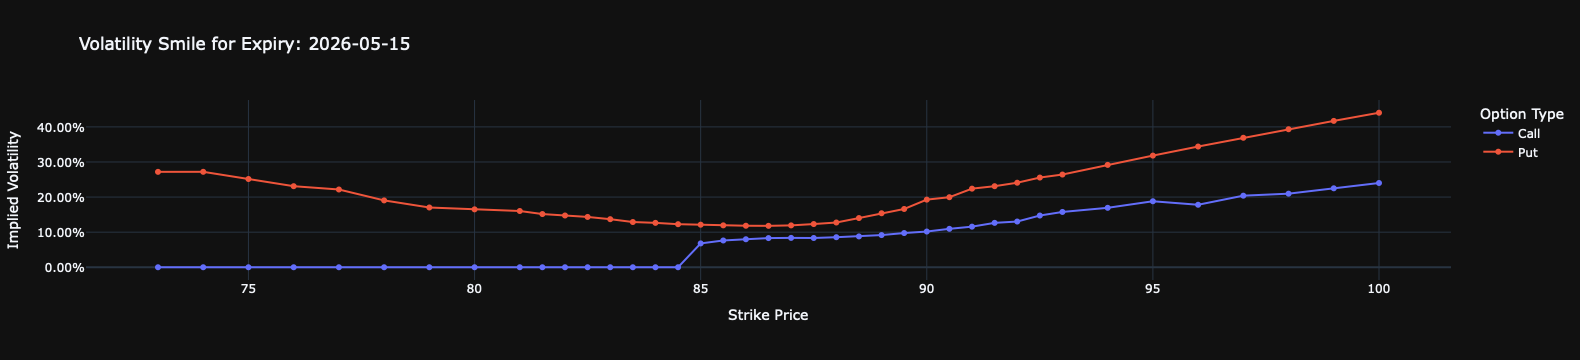

In [3]:
import plotly.express as px

# Choose an expiration
# target_expiry = options_df['Expiration'].max()
target_expiry = pd.to_datetime("2026-05-15")

# Look at options on only that expiry
df_smile = options_df[options_df['Expiration'] == target_expiry]

# Plot IV vs. Strike, coloring by Call vs. Put
fig_smile = px.line(
    df_smile, 
    x='Strike', 
    y='IV', 
    color='Option Type', 
    markers=True,
    hover_data=['Bid', 'Ask', 'Volume', 'Open Int'], # Crucial for spotting illiquid outliers
    title=f"Volatility Smile for Expiry: {target_expiry.strftime('%Y-%m-%d')}",
    labels={'IV': 'Implied Volatility', 'Strike': 'Strike Price'}
)

fig_smile.update_layout(template="plotly_dark", hovermode="x unified")
fig_smile.update_layout(yaxis=dict(tickformat=".2%"))
fig_smile.show()

Observations:
* Puts show typical vol smile shape, but the shape deteriorates with calls below spot (~86.5)
* Put and Call IV differs significantly (in theory, they should be the same)
* Several calls with 0 IV (looking at options_df, most of these are due to low open interest (OI) or no volume, but there are some liquid instances with 0 IV still)

Notes:
* Reasons why put and call IVs can differ:
    * Demand imbalances (While there are more calls than puts by volume and OI, the puts still cost slighlty more "premium" for the downside protection)
    * Early Exercise premium (Greater for puts than calls, bc you can gain \$K and begin earning interest on it)
    * Numerical instability for ITM options (when deep ITM, the option's value is almost intirely intrinsic, so the vega [sensitivity to vol, timed to time-value of an option] approaches 0 which can lead to numerical instability)
* When calibrating a Heston, we will **use OTM/ATM options only** (OTM typically more liquid, greater vega per $, so more informative regarding vol, and avoids instability issues mentioned above)
    * Between this and some basic filtering to remove stale IVs due to illiquid options, this should fix our issues
    * IV jump ATM when switching from puts to calls: **shouldn't cause an issue, but can revisit if calibration looks off**

In [4]:
# Is their a demand imbalance?
call_vol = options_df[options_df['Option Type'] == 'Call']['Volume'].sum()
put_vol = options_df[options_df['Option Type'] == 'Put']['Volume'].sum()

call_oi = options_df[options_df['Option Type'] == 'Call']['Open Int'].sum()
put_oi = options_df[options_df['Option Type'] == 'Put']['Open Int'].sum()

print(f"Call volume: {call_vol}")
print(f"Put volume: {put_vol}")
print(f"Call Open Interest: {call_oi}")
print(f"Call Open Interest: {put_oi}")

Call volume: 101304
Put volume: 31777
Call Open Interest: 1939867
Call Open Interest: 1231133


Volume and OI demand does not accurately represent skew. We're looking for **pricing differences** where the puts are priced higher than the calls, which is shown by the IVs.

---
### Options Data: Filtering
Filters:
* OTM only (we'll use 86.5 as our ATM. When ATM we'll keep whicher has higer OI)
* Drop 0% IV rows (OTM only should get rid of most of these, but still good to check)
* Drop bid $ \leq 0.05 $ (these are "dead" quotes because such a small bid indicates no one is seriously looking to buy)
* Drop OI $ \leq 100 $ (illiquid)
* Drop Last Trade > 5 days old (from 4-25, this means the quote is stale)
* Drop relative spread $ \geq 20% $ (overly wide spreads are typically stale)

In [5]:
# Want to see how many options are removed by filtering
print(f"Number of options before cleaning: {options_df.shape[0]}")

# Closest strike price to spot price at the time of pulling data
S = 86.71

# Create an OTM mask
otm_mask = (
    ((options_df['Option Type'] == 'Call') & (options_df['Strike'] > S + 0.5)) |
    ((options_df['Option Type'] == 'Put') & (options_df['Strike'] < S - 0.5))
)

# For strikes that are ATM (within $0.50 of spot), we keep the higher OI option
atm_mask = abs(options_df['Strike'] - S) <= 0.5
atm_df = (options_df[atm_mask]
    .sort_values('Open Int', ascending= False)
    .drop_duplicates(subset =['Expiration', 'Strike'], keep='first')
)

# Filter options_df by OTM and combine with atm_df
cleaned_options = pd.concat([options_df[otm_mask], atm_df])

# Sort for readability
cleaned_options = cleaned_options.sort_values(by = ['Expiration', 'Strike'], ascending = True)

print(f"Number of options after removing ITM: {cleaned_options.shape[0]}")

# Drop any 0% IV (not needed, none)
cleaned_options = cleaned_options[cleaned_options['IV'] > 0.0]

# Drop bid <= 0.5 (removes 60)
cleaned_options = cleaned_options[cleaned_options['Bid'] > 0.05]

# Drop OI <= 100 (not needed, none)
cleaned_options = cleaned_options[cleaned_options['Open Int'] > 100]

# Define relative spread, then drop where spread >= 20% (removes 3)
cleaned_options['Rel Spread'] = (cleaned_options['Ask'] - cleaned_options['Bid']) / cleaned_options['Mid']
cleaned_options = cleaned_options[cleaned_options['Rel Spread'] < 0.2]

# Drop Last Trade > 5 days before 4-25
cleaned_options = cleaned_options[cleaned_options['Last Trade'] >= pd.to_datetime('4/20/26')]

print(f"Number of options after filtering: {cleaned_options.shape[0]}")

Number of options before cleaning: 442
Number of options after removing ITM: 221
Number of options after filtering: 148


148 strikes should be plently for calibration. Now let's look at the volatility smiles for different expirations and see if the smile looks correct.

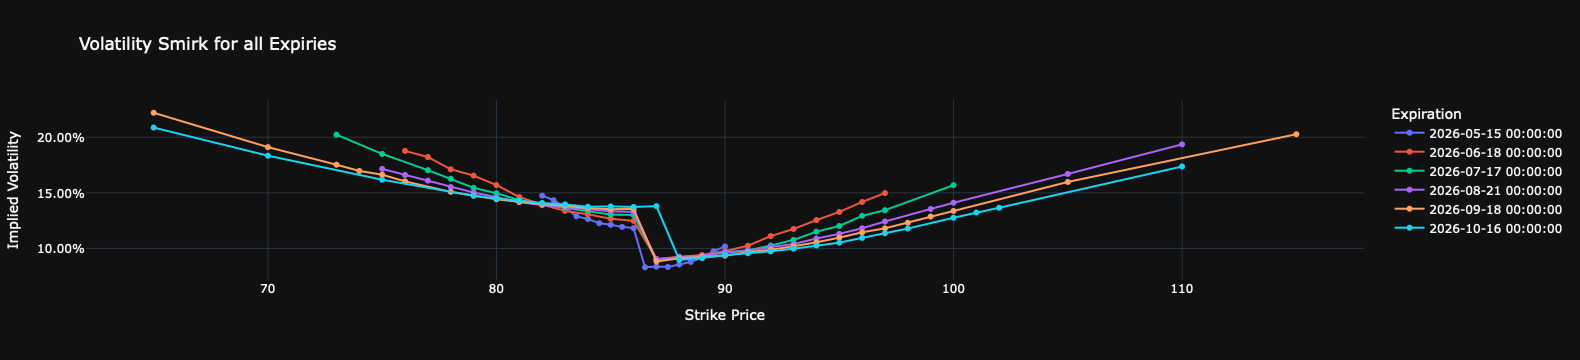

In [6]:
# Look at all expirations
df_smile = cleaned_options

# Plot IV vs. Strike
fig_smile = px.line(
    df_smile, 
    x='Strike', 
    y='IV',
    color='Expiration',
    markers=True,
    hover_data=['Bid', 'Ask', 'Option Type', 'Volume', 'Open Int'],
    title="Volatility Smirk for all Expiries",
    labels={'IV': 'Implied Volatility', 'Strike': 'Strike Price'}
)

fig_smile.update_layout(template="plotly_dark", hovermode="x unified")
fig_smile.update_layout(yaxis=dict(tickformat=".2%"))
fig_smile.show()

This looks great. Each expiration shows a typical volatility smirk (smirk not a smile because overall slope is steeper on the left and more gradual on the right). There is a slight crash in IV as we switch from puts to calls (position of when the crash occurs differs slightly depending on if ATM call/put was used), but this shouldn't be an issue. Additionally we see that the range of strike prices is shorter for May expiry, but this also makes sense as further OTM options are less likely to be liquid with the shorter time to expiry. 

In [7]:
# Export cleaned data
cleaned_options.to_csv("../data/options/Cleaned Options.csv", index=False)